In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from pytorch3d.vis.plotly_vis import plot_scene
from data_tools import adv_dataset, adversarial_patch_3d

from attack_utils import *

CKPT_PATH = "output/train/loss_ablation/pointrcnn/misrecognize_9/final_adversarial_patch_checkpoint.pt"

In [6]:
state_dict = torch.load(CKPT_PATH)

In [7]:
universal_adv_patch_car = single_sphere(scale=adv_dataset.CAR_ADV_PATCH_SCALE)
universal_adv_patch_car.load_parameter(state_dict["universal_adv_patch_car"])

print(state_dict["universal_adv_patch_car"])

mesh vertex count : torch.Size([162, 3])
[tensor([ 0.9123, -0.9070,  0.0000], device='cuda:0', requires_grad=True), tensor([2.1500], device='cuda:0', requires_grad=True), tensor([[ -1.4470,  -8.0248,   0.0000],
        [ -4.2390,  -1.9210,   0.0000],
        [ -6.9555,  -2.0150,   0.0000],
        [ -1.3071,  -1.9581,   0.0000],
        [  0.0000,  -3.1203,   0.0000],
        [  0.0000,  -3.1112,   0.0000],
        [  0.0000,   6.7239,   0.0000],
        [  0.0000,   1.2151,   0.0000],
        [ -1.7384,   0.0000,   0.0000],
        [ -3.7962,   0.0000,   0.0000],
        [  9.5595,   0.0000,   0.0000],
        [ -4.8744,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000],
        [ -4.0622,  -8.9614,   0.0000],
        [ -0.3824,  -3.8547,   0.0000],
        [  7.4154,   7.1462,   0.0000],
        [ -6.7214,  -5.9907,   0.0000],
        [ -2.0328,  -3.4189,   0.0000],
        [  6.3179,   1.3692,   0.0000],
        [ -3.1451,  -1.3632,   0.0000],
        [ -5.6503,  -3.2484, 

In [8]:
fig = plot_scene({
                    "original": {
                        "mesh_1": universal_adv_patch_car.get_basic_meshes()
                    },
                    "adversarial": {
                        "mesh_1": universal_adv_patch_car.get_deformed_meshes()
                    },
                }, ncols=2)
fig.update_layout(height=400, width=800)
fig.show()

In [3]:
from data_tools import simple_cubic_meshes, join_meshes_as_batch
from pytorch3d.vis.plotly_vis import plot_scene

test = simple_cubic_meshes(cubic_level=2)
meshes_batch = join_meshes_as_batch(test.get_deformed_lattice())

In [4]:
fig = plot_scene({
                    "original": {
                        "mesh_1": meshes_batch
                    }
                }, ncols=1)
fig.update_layout(height=400, width=400)
fig.show()

In [6]:
import pandas as pd

def parse_table(data):
    # 将数据转换为DataFrame
    lines = data.strip().split('\n')
    rows = [line.split() for line in lines]
    columns = ["Category", "Value1", "Value2", "Value3", "Value4"]

    df = pd.DataFrame(rows, columns=columns)

    # 将数值列转换为浮点数
    df[["Value1", "Value2", "Value3", "Value4"]] = df[["Value1", "Value2", "Value3", "Value4"]].astype(float)

    print(df)

    clean_values = df.loc[df['Category'] == 'Clean', ["Value1", "Value2", "Value3", "Value4"]].values[0]

    # 计算每个类别相对于Clean的百分比
    percentage_df = df.copy()
    percentage_df[["Value1", "Value2", "Value3", "Value4"]] = 100 - df[["Value1", "Value2", "Value3", "Value4"]].div(clean_values) * 100

    print("Original DataFrame:")
    print(df)
    print("\nPercentage DataFrame:")
    print(percentage_df)

In [9]:
data_1 = """
Vanilla@BEV	76.9694	83.1086	88.1049	87.5583
Vanilla@3D	66.5986	66.2274	76.1004	73.9477
Car@BEV	76.8111	81.9277	87.8725	87.3614
Car@3D	65.8241	64.8201	75.0164	72.1968
"""

data_2 = """
Vanilla@BEV	76.9694	83.1086	88.1049	87.5583
Vanilla@3D	66.5986	66.2274	76.1004	73.9477
Car@BEV	76.8111	81.9277	87.8725	87.3614
Car@3D	65.8241	64.8201	75.0164	72.1968
"""


parse_table(data_1)

parse_table(data_2)

      Category   Value1   Value2   Value3   Value4
0        Clean  86.7564  85.6744  88.9160  89.1513
1      Vanilla  80.6136  76.9694  83.1086  88.1049
2   FullAttack  79.4522  74.2181  86.4966  77.4980
3    IouFrozen  78.6085  72.7279  86.9074  76.9161
4  LogitFrozen  76.5190  74.8475  85.5587  76.4687
Original DataFrame:
      Category   Value1   Value2   Value3   Value4
0        Clean  86.7564  85.6744  88.9160  89.1513
1      Vanilla  80.6136  76.9694  83.1086  88.1049
2   FullAttack  79.4522  74.2181  86.4966  77.4980
3    IouFrozen  78.6085  72.7279  86.9074  76.9161
4  LogitFrozen  76.5190  74.8475  85.5587  76.4687

Percentage DataFrame:
      Category     Value1     Value2    Value3     Value4
0        Clean   0.000000   0.000000  0.000000   0.000000
1      Vanilla   7.080515  10.160561  6.531333   1.173735
2   FullAttack   8.419206  13.371906  2.720995  13.071374
3    IouFrozen   9.391699  15.111282  2.258986  13.724085
4  LogitFrozen  11.800167  12.637264  3.775811  14.2259

In [1]:
import pandas as pd
import numpy as np
def parse_table(data):
    # 将数据转换为DataFrame
    lines = data.strip().split('\n')
    rows = [line.split() for line in lines[1:]]
    columns = lines[0].split()
    
    df = pd.DataFrame(rows, columns=columns)

    # 将数值列转换为浮点数
    df[columns[1:]] = df[columns[1:]].astype(float)

    print(df)
    
    return df

    # clean_values = df.loc[df['Category'] == 'Clean', ["Value1", "Value2", "Value3", "Value4"]].values[0]

    # # 计算每个类别相对于Clean的百分比
    # percentage_df = df.copy()
    # percentage_df[["Value1", "Value2", "Value3", "Value4"]] = 100 - df[["Value1", "Value2", "Value3", "Value4"]].div(clean_values) * 100

    # print("Original DataFrame:")
    # print(df)
    # print("\nPercentage DataFrame:")
    # print(percentage_df)


In [19]:
table_1 = """
Metric	PointRCNN	PVRCNN	VoxelRCNN(Car)	Second
Clean@BEV	85.6744	88.9160	89.1513	88.7158
Clean@3D	78.6668	66.2274	76.1004	73.9477
Vanilla@BEV	76.9694	83.1086	88.1049	87.5583
Vanilla@3D	66.5986	66.2274	76.1004	73.9477
Car@BEV	76.8111	81.9277	87.8725	87.3614
Car@3D	65.8241	64.8201	75.0164	72.1968
"""
table_1:pd.DataFrame = parse_table(table_1)
clean_bev = table_1.loc[table_1['Metric'] == 'Clean@BEV'].values[0, 1:].astype(float)
clean_3d = table_1.loc[table_1['Metric'] == 'Clean@3D'].values[0, 1:].astype(float)
car_bev = table_1.loc[table_1['Metric'] == 'Car@BEV'].values[0, 1:].astype(float)
car_3d = table_1.loc[table_1['Metric'] == 'Car@3D'].values[0, 1:].astype(float)
# table_1 = table_1.append(new_row, ignore_index=True)
print(np.round((1 - (car_bev/clean_bev))*100, 2))
print(np.round((1 - (car_3d/clean_3d))*100, 2))

        Metric  PointRCNN   PVRCNN  VoxelRCNN(Car)   Second
0    Clean@BEV    85.6744  88.9160         89.1513  88.7158
1     Clean@3D    78.6668  66.2274         76.1004  73.9477
2  Vanilla@BEV    76.9694  83.1086         88.1049  87.5583
3   Vanilla@3D    66.5986  66.2274         76.1004  73.9477
4      Car@BEV    76.8111  81.9277         87.8725  87.3614
5       Car@3D    65.8241  64.8201         75.0164  72.1968
[10.35  7.86  1.43  1.53]
[16.33  2.12  1.42  2.37]


In [22]:
table_1 = """
Metric	PointPIllar	PVRCNN	VoxelRCNN(Car)	Second
Clean@BEV	86.7564	88.9160	89.1513	88.7158
Clean@3D	77.5743	66.2274	76.1004	73.9477
Vanilla@BEV	80.6136	83.1086	88.1049	87.5583
Vanilla@3D	57.1795	66.2274	76.1004	73.9477
Car@BEV	79.3103	82.9085	82.7351	86.9980
Car@3D	53.3262	66.0200	65.8373	69.7959
"""
table_1:pd.DataFrame = parse_table(table_1)
clean_bev = table_1.loc[table_1['Metric'] == 'Clean@BEV'].values[0, 1:].astype(float)
clean_3d = table_1.loc[table_1['Metric'] == 'Clean@3D'].values[0, 1:].astype(float)
car_bev = table_1.loc[table_1['Metric'] == 'Car@BEV'].values[0, 1:].astype(float)
car_3d = table_1.loc[table_1['Metric'] == 'Car@3D'].values[0, 1:].astype(float)
# table_1 = table_1.append(new_row, ignore_index=True)
print(np.round((1 - (car_bev/clean_bev))*100, 2))
print(np.round((1 - (car_3d/clean_3d))*100, 2))

        Metric  PointPIllar   PVRCNN  VoxelRCNN(Car)   Second
0    Clean@BEV      86.7564  88.9160         89.1513  88.7158
1     Clean@3D      77.5743  66.2274         76.1004  73.9477
2  Vanilla@BEV      80.6136  83.1086         88.1049  87.5583
3   Vanilla@3D      57.1795  66.2274         76.1004  73.9477
4      Car@BEV      79.3103  82.9085         82.7351  86.9980
5       Car@3D      53.3262  66.0200         65.8373  69.7959
[8.58 6.76 7.2  1.94]
[31.26  0.31 13.49  5.61]


In [23]:
table_1 = """
Metric	PointPIllar	PVRCNN	VoxelRCNN(Car)	Second
Clean@BEV	86.7564	88.9160	89.1513	88.7158
Clean@3D	77.5743	66.2274	76.1004	73.9477
Vanilla@BEV	80.6136	83.1086	88.1049	87.5583
Vanilla@3D	57.1795	66.2274	76.1004	73.9477
Car@BEV	80.0401	82.2935	87.8767	87.2270
Car@3D	56.2568	64.8246	74.1950	70.3205
"""
table_1:pd.DataFrame = parse_table(table_1)
clean_bev = table_1.loc[table_1['Metric'] == 'Clean@BEV'].values[0, 1:].astype(float)
clean_3d = table_1.loc[table_1['Metric'] == 'Clean@3D'].values[0, 1:].astype(float)
car_bev = table_1.loc[table_1['Metric'] == 'Car@BEV'].values[0, 1:].astype(float)
car_3d = table_1.loc[table_1['Metric'] == 'Car@3D'].values[0, 1:].astype(float)
# table_1 = table_1.append(new_row, ignore_index=True)
print(np.round((1 - (car_bev/clean_bev))*100, 2))
print(np.round((1 - (car_3d/clean_3d))*100, 2))

        Metric  PointPIllar   PVRCNN  VoxelRCNN(Car)   Second
0    Clean@BEV      86.7564  88.9160         89.1513  88.7158
1     Clean@3D      77.5743  66.2274         76.1004  73.9477
2  Vanilla@BEV      80.6136  83.1086         88.1049  87.5583
3   Vanilla@3D      57.1795  66.2274         76.1004  73.9477
4      Car@BEV      80.0401  82.2935         87.8767  87.2270
5       Car@3D      56.2568  64.8246         74.1950  70.3205
[7.74 7.45 1.43 1.68]
[27.48  2.12  2.5   4.91]


In [3]:
table_1 = """
Metric	PointPIllar		VoxelRCNN(Car)	Second	PointRCNN
Clean@BEV	86.7564	89.1513	88.7158	85.6744
Clean@3D	77.5743	76.1004	73.9477	78.6668
Vanilla@BEV	80.6136		88.1049	87.5583	76.9694
Vanilla@3D	57.1795		76.1004	73.9477	66.5986
Car@BEV	79.3931		88.0110	86.8020	76.7037
Car@3D	54.5816		75.2899	70.1040	65.7802
"""
table_1:pd.DataFrame = parse_table(table_1)
clean_bev = table_1.loc[table_1['Metric'] == 'Clean@BEV'].values[0, 1:].astype(float)
clean_3d = table_1.loc[table_1['Metric'] == 'Clean@3D'].values[0, 1:].astype(float)
car_bev = table_1.loc[table_1['Metric'] == 'Car@BEV'].values[0, 1:].astype(float)
car_3d = table_1.loc[table_1['Metric'] == 'Car@3D'].values[0, 1:].astype(float)
# table_1 = table_1.append(new_row, ignore_index=True)
print(np.round((1 - (car_bev/clean_bev))*100, 2))
print(np.round((1 - (car_3d/clean_3d))*100, 2))

        Metric  PointPIllar  VoxelRCNN(Car)   Second  PointRCNN
0    Clean@BEV      86.7564         89.1513  88.7158    85.6744
1     Clean@3D      77.5743         76.1004  73.9477    78.6668
2  Vanilla@BEV      80.6136         88.1049  87.5583    76.9694
3   Vanilla@3D      57.1795         76.1004  73.9477    66.5986
4      Car@BEV      79.3931         88.0110  86.8020    76.7037
5       Car@3D      54.5816         75.2899  70.1040    65.7802
[ 8.49  1.28  2.16 10.47]
[29.64  1.07  5.2  16.38]


In [1]:
import os
import re
import json
from collections import defaultdict


STEP_ABLATION_ROOT_PATH = "output/train/step_ablation"

def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"([a-zA-Z_]+)_([a-zA-Z]+)_([\d\.]+)", folder_name)
    if match:
        model_name = match.group(1)
        attack_method = match.group(2)
        parameter = match.group(3)
        return model_name, attack_method, parameter
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "evaluation_result.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        if os.path.isdir(folder_path):
            extracted_info = extract_info_from_folder(folder_name)
            if extracted_info:
                model_name, attack_method, parameter = extracted_info

                # 读取 evaluation_result.json 文件
                evaluation_result = read_evaluation_result_json(folder_path)

                # 按照模型名称和参数归类
                model_dict[model_name][parameter] = {
                    "path": folder_path,
                    "attack_method": attack_method,
                    "evaluation_result": evaluation_result
                }

    return model_dict

model_dict = get_folder_info_by_model(STEP_ABLATION_ROOT_PATH)


model_graph = {}
# 打印结果
for model_name, parameters in model_dict.items():
    print(f"Model: {model_name}")
    model_graph[model_name] = {"car_bev": [], "car_3d": []}
    
    for step_size in ["0.5", "0.05","0.005", "0.0005", "0.00005"]:
        info = parameters[step_size]
        
        car_3d = info['evaluation_result']['Car_3d/moderate']
        car_bev = info['evaluation_result']['Car_bev/moderate']
        model_graph[model_name]["car_bev"].append(car_bev)
        model_graph[model_name]["car_3d"].append(car_3d)
        
    print(f"length of car_bev:{model_graph[model_name]['car_bev'].__len__()}")
    print(f"length of car_3d:{model_graph[model_name]['car_3d'].__len__()}")
        # print(f"  Info: {info}")
print(model_graph)

Model: second
length of car_bev:5
length of car_3d:5
Model: voxel_rcnn_car
length of car_bev:5
length of car_3d:5
Model: pointpillar
length of car_bev:5
length of car_3d:5
Model: pvrcnn
length of car_bev:5
length of car_3d:5
Model: pointrcnn
length of car_bev:5
length of car_3d:5
{'second': {'car_bev': [86.6269387377873, 86.55008572857487, 84.57790715710185, 81.82689099095586, 81.55010060844428], 'car_3d': [76.39276735961576, 75.75621963986376, 72.37335328011653, 67.73616709511447, 66.93546466996445]}, 'voxel_rcnn_car': {'car_bev': [76.37049423331722, 76.07264438763004, 77.42204613822268, 75.71585686447752, 76.305114312677], 'car_3d': [65.85072621600277, 66.84557813076218, 68.65215218568541, 60.16410159938196, 59.87089820894036]}, 'pointpillar': {'car_bev': [78.82378606285648, 68.05459460338521, 66.29160207296641, 79.58342307897607, 80.78602594349559], 'car_3d': [63.00712889533706, 44.57798937385321, 43.09061684930828, 55.45992628203151, 57.333618400624175]}, 'pvrcnn': {'car_bev': [81.

In [2]:
import pandas as pd
# import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def parse_table(data):
    # 将数据转换为DataFrame
    lines = data.strip().split('\n')
    rows = [line.split() for line in lines[1:]]
    columns = lines[0].split()
    
    df = pd.DataFrame(rows, columns=columns)

    # 将数值列转换为浮点数
    df[columns[1:]] = df[columns[1:]].astype(float)
    
    return df

table_1 = """
Model@lr	PointRCNN@0.5	PointRCNN@0.05	PointRCNN@0.005	PointRCNN@0.0005	PointRCNN@0.00005
Car@BEV(IFGSM)	73.7186	73.9964	76.4810	77.0568	76.9188
Car@3D(IFGSM)	62.5936	62.2509	65.4640	65.9328	66.0451
Car@BEV(Adam)	63.5294	64.1308	72.4848	76.4491	77.0371
Car@3D(Adam)	50.8117	50.6058	61.0131	65.5077	65.8303
"""

table_1 = parse_table(table_1)

table_2 = """
Model@lr	PointPillar@0.5	PointPillar@0.05	PointPillar@0.005	PointPillar@0.0005	PointPillar@0.00005
Car@BEV(IFGSM)	74.7179	76.7819	79.5679	80.3516	80.7451
Car@3D(IFGSM)	42.3016	46.0600	54.0880	56.7081	57.2705
Car@BEV(Adam)	74.8059	75.7801	79.2733	80.2302	80.9181
Car@3D(Adam)	49.7496	48.5106	56.7255	57.5994	57.2783
"""

table_2 = parse_table(table_2)

table_3 = """
Model@lr	PVRCNN@0.5	PVRCNN@0.05	PVRCNN@0.005	PVRCNN@0.0005	PVRCNN@0.00005
Car@BEV(IFGSM)	81.8204	81.6676	75.4499	80.7042	81.0519
Car@3D(IFGSM)	58.3808	62.2472	52.8814	57.1060	57.8906
Car@BEV(Adam)	82.4894	82.6652	81.6014	81.0678	81.0859
Car@3D(Adam)	63.4156	63.1228	59.8393	58.3011	57.9622
"""

table_3 = parse_table(table_3)

table_4 = """
Model@lr	VoxelRCNN@0.5	VoxelRCNN@0.05	VoxelRCNN@0.005	VoxelRCNN@0.0005	VoxelRCNN@0.00005
Car@BEV(IFGSM)	75.6491	75.7126	76.3095	75.8909	76.0998
Car@3D(IFGSM)	64.6322	64.5856	64.4498	59.4109	59.8451
Car@BEV(Adam)	76.3462	77.4697	77.4458	75.7331	76.1522
Car@3D(Adam)	64.5041	66.4997	67.6613	60.2458	59.9528
"""

table_4 = parse_table(table_4)

table_5 = """
Model@lr	SECOND@0.5	SECOND@0.05	SECOND@0.005	SECOND@0.0005	SECOND@0.00005
Car@BEV(IFGSM)	83.3245	82.6507	83.6077	81.6649	81.3468
Car@3D(IFGSM)	71.0220	71.1782	73.5252	66.5171	66.3696
Car@BEV(Adam)	86.3404	86.6090	85.5537	82.0886	81.6318
Car@3D(Adam)	76.1328	76.3723	72.1165	67.4521	66.8208
"""

table_5 = parse_table(table_5)


/tmp/ipykernel_4174892/736155661.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[2][0])
/tmp/ipykernel_4174892/736155661.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[3][0])


Car@BEV(Adam)
Car@3D(Adam)
PointRCNN
(0.5,62.70) (0.05,66.23) (0.005,72.24) (0.0005,76.38) (0.00005,76.94) 
(0.5,48.78) (0.05,52.72) (0.005,60.54) (0.0005,65.20) (0.00005,65.98) 

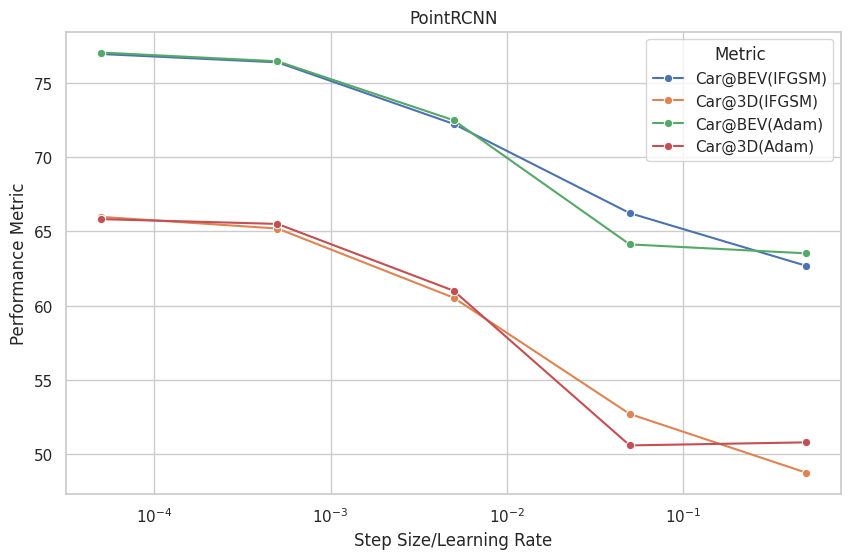

/tmp/ipykernel_4174892/736155661.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[2][0])
/tmp/ipykernel_4174892/736155661.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[3][0])


Car@BEV(Adam)
Car@3D(Adam)
PointPillar
(0.5,78.82) (0.05,68.05) (0.005,66.29) (0.0005,79.58) (0.00005,80.79) 
(0.5,63.01) (0.05,44.58) (0.005,43.09) (0.0005,55.46) (0.00005,57.33) 

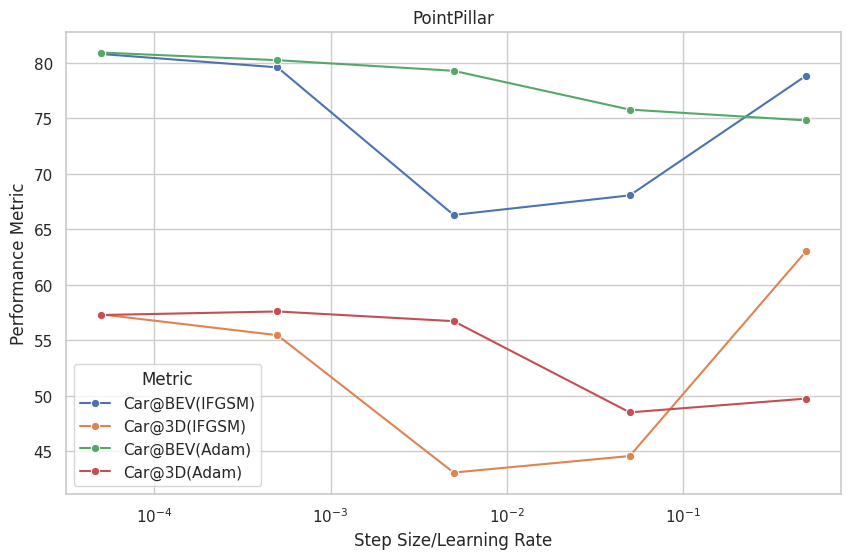

/tmp/ipykernel_4174892/736155661.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[2][0])
/tmp/ipykernel_4174892/736155661.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[3][0])


Car@BEV(Adam)
Car@3D(Adam)
PVRCNN
(0.5,81.94) (0.05,84.61) (0.005,82.03) (0.0005,81.08) (0.00005,81.07) 
(0.5,62.36) (0.05,59.38) (0.005,60.14) (0.0005,58.31) (0.00005,57.86) 

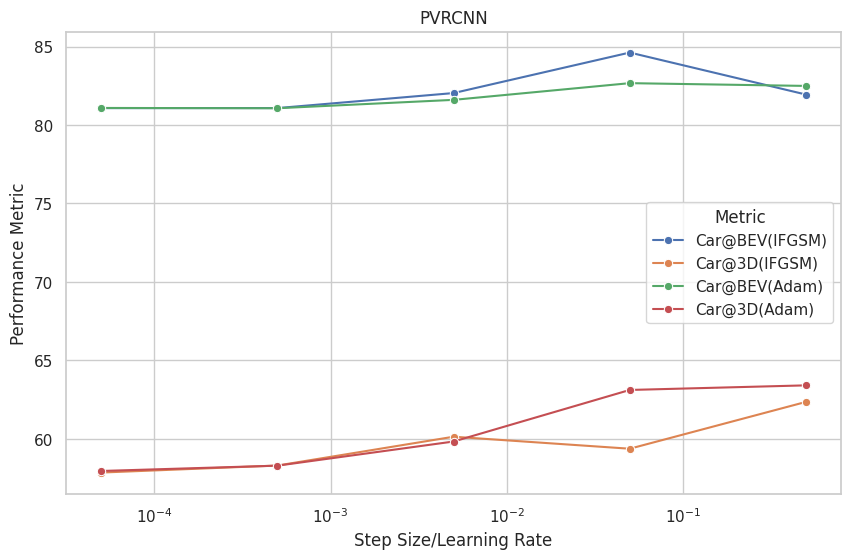

/tmp/ipykernel_4174892/736155661.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[2][0])
/tmp/ipykernel_4174892/736155661.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[3][0])


Car@BEV(Adam)
Car@3D(Adam)
VoxelRCNN
(0.5,76.37) (0.05,76.07) (0.005,77.42) (0.0005,75.72) (0.00005,76.31) 
(0.5,65.85) (0.05,66.85) (0.005,68.65) (0.0005,60.16) (0.00005,59.87) 

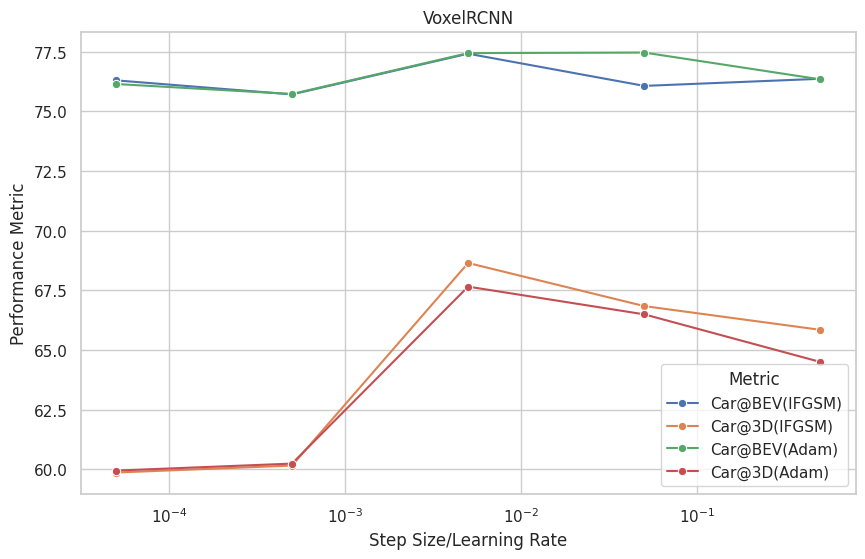

/tmp/ipykernel_4174892/736155661.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[2][0])
/tmp/ipykernel_4174892/736155661.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[3][0])


Car@BEV(Adam)
Car@3D(Adam)
SECOND
(0.5,86.63) (0.05,86.55) (0.005,84.58) (0.0005,81.83) (0.00005,81.55) 
(0.5,76.39) (0.05,75.76) (0.005,72.37) (0.0005,67.74) (0.00005,66.94) 

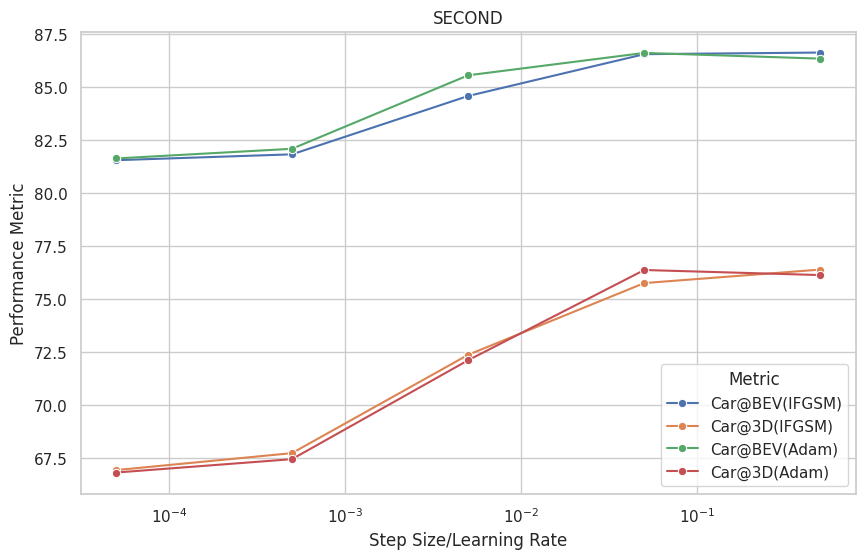

Car@BEV(Adam)
Car@3D(Adam)
SECOND


/tmp/ipykernel_4174892/736155661.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[2][0])
/tmp/ipykernel_4174892/736155661.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print( table.iloc[3][0])


(array([86.3404, 86.609 , 85.5537, 82.0886, 81.6318]),
 array([76.1328, 76.3723, 72.1165, 67.4521, 66.8208]))

In [14]:
import seaborn as sns

def parse_pd(table):
    model_name = table.columns[1].split('@')[0]
    car_bev = table.iloc[2][1:].to_numpy().astype(float)
    car_3d = table.iloc[3][1:].to_numpy().astype(float)
    print( table.iloc[2][0])
    print( table.iloc[3][0])
    print(model_name)
    
    return car_bev, car_3d

def parse_graph(car_bev_ifgsm, 
                car_3d_ifgsm,
                car_bev_adam,
                car_3d_adam, title:str):
    data = {
        'step size/learning rate': [0.5, 0.05, 0.005, 0.0005, 0.00005],
        "Car@BEV(IFGSM)": car_bev_ifgsm,
        "Car@3D(IFGSM)": car_3d_ifgsm,
        "Car@BEV(Adam)": car_bev_adam,
        "Car@3D(Adam)": car_3d_adam,
        
    }

    df = pd.DataFrame(data)

    # 将数据转换为长格式（long-form），以便使用 seaborn 进行可视化
    df_melted = df.melt('step size/learning rate', var_name='Metric', value_name='Value')

    # 绘制折线图
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_melted, x='step size/learning rate', y='Value', hue='Metric', marker='o')

    # 设置图表标题和轴标签
    plt.title('Performance Metrics vs. Step Size/Learning Rate')
    plt.xlabel('Step Size/Learning Rate')
    plt.ylabel('Performance Metric')
    plt.title(title)
    plt.xscale('log')

    # 显示图例
    plt.legend(title='Metric')

    # 显示图表
    plt.show()
    # 设置Seaborn样式
    
    # sns.set(style="whitegrid")
    # sns.lineplot(x='step size/learning rate', y=df.loc[1].values[0], data=df, marker='o', label=df.loc[1].values[0], color='blue', linestyle='-')
    # sns.lineplot(x='step size/learning rate', y=df.loc[2].values[0], data=df, marker='o', label=df.loc[2].values[0], color='blue', linestyle='--')
    # sns.lineplot(x='step size/learning rate', y=df.loc[3].values[0], data=df, marker='o', label=df.loc[3].values[0], color='red', linestyle='-')
    # sns.lineplot(x='step size/learning rate', y=df.loc[4].values[0], data=df, marker='o', label=df.loc[4].values[0], color='red', linestyle='--')
    # plt.title(title)
    # plt.xscale('log')
    # plt.legend()
    # plt.show()

car_bev_ifgsm, car_3d_ifgsm = model_graph["pointrcnn"]["car_bev"], model_graph["pointrcnn"]["car_3d"]
car_bev_adam, car_3d_adam = parse_pd(table_1)
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_bev_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
print()
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_3d_ifgsm):
    print(f"({step},{y:.2f})", end=' ')

parse_graph(car_bev_ifgsm, car_3d_ifgsm, car_bev_adam, car_3d_adam, "PointRCNN")

car_bev_ifgsm, car_3d_ifgsm = model_graph["pointpillar"]["car_bev"], model_graph["pointpillar"]["car_3d"]
car_bev_adam, car_3d_adam = parse_pd(table_2)
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_bev_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
print()
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_3d_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
parse_graph(car_bev_ifgsm, car_3d_ifgsm, car_bev_adam, car_3d_adam, "PointPillar")

car_bev_ifgsm, car_3d_ifgsm = model_graph["pvrcnn"]["car_bev"], model_graph["pvrcnn"]["car_3d"]
car_bev_adam, car_3d_adam = parse_pd(table_3)
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_bev_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
print()
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_3d_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
parse_graph(car_bev_ifgsm, car_3d_ifgsm, car_bev_adam, car_3d_adam, "PVRCNN")


car_bev_ifgsm, car_3d_ifgsm = model_graph["voxel_rcnn_car"]["car_bev"], model_graph["voxel_rcnn_car"]["car_3d"]
car_bev_adam, car_3d_adam = parse_pd(table_4)
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_bev_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
print()
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_3d_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
parse_graph(car_bev_ifgsm, car_3d_ifgsm, car_bev_adam, car_3d_adam, "VoxelRCNN")

car_bev_ifgsm, car_3d_ifgsm = model_graph["second"]["car_bev"], model_graph["second"]["car_3d"]
car_bev_adam, car_3d_adam = parse_pd(table_5)
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_bev_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
print()
for step, y in zip(["0.5", "0.05", "0.005", "0.0005", "0.00005"], car_3d_ifgsm):
    print(f"({step},{y:.2f})", end=' ')
parse_graph(car_bev_ifgsm, car_3d_ifgsm, car_bev_adam, car_3d_adam, "SECOND")


parse_pd(table_5)


# table_1.iloc[2][1:].to_numpy().astype(float)
# table_1.iloc[2][1:].to_numpy().astype(float)
# table_1.columns[1]



PointRCNN
(0.05,66.23)
(0.05,52.72)

PointPillar
(0.005,66.29)
(0.005,43.09)

PVRCNN
(0.0005,81.08)
(0.0005,58.31) 

VoxelRCNN
(0.0005,75.72) 
(0.0005,60.16)

SECOND
(0.0005,81.83)
(0.0005,67.74)

In [1]:
import os
import re
import json
from collections import defaultdict


STEP_ABLATION_ROOT_PATH = "output/train/scale_ablation"
LEVEL_ABLATION_ROOT_PATH = "output/train/level_ablation"

# PointRCNN PointPillar PVRCNN VoxelRCNN SECOND
NORMAL_STEP = ["0.05", "0.005", "0.0005", "0.0005", "0.0005"]

NORMAL_SCALE_ = [81.6318]

def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"([a-zA-Z_\d]+)_([\d.]+)_([\d.]+)_([\d.]+)", folder_name)
    if match:
        attack_method = match.group(1)
        scale_1 = match.group(2)
        return attack_method, scale_1
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "evaluation_result.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        if os.path.isdir(folder_path):
            extracted_info = extract_info_from_folder(folder_name)
            if extracted_info:
                attack_method, parameter = extracted_info
                # 读取 evaluation_result.json 文件
                evaluation_result = read_evaluation_result_json(folder_path)

                # 按照模型名称和参数归类
                model_dict[attack_method][parameter] = {
                    "evaluation_result": evaluation_result
                }
            

    return model_dict

model_dict = get_folder_info_by_model(STEP_ABLATION_ROOT_PATH)

# print(model_dict)

model_graph = {}
# 打印结果
for model_name, parameters in model_dict.items():
    # print(f"Model: {model_name}")
    model_graph[model_name] = {"car_bev": [], "car_3d": []}
    
    for step_size in ["0.5", "0.6", "0.8","0.9", "1.0"]:
        info = parameters[step_size]
        
        if info['evaluation_result'] is None:
            continue
        car_3d = info['evaluation_result']['Car_3d/moderate']
        car_bev = info['evaluation_result']['Car_bev/moderate']
        model_graph[model_name]["car_bev"].append(car_bev)
        model_graph[model_name]["car_3d"].append(car_3d)
        
    # print(f"length of car_bev:{model_graph[model_name]['car_bev'].__len__()}")
    # print(f"length of car_3d:{model_graph[model_name]['car_3d'].__len__()}")
        # print(f"  Info: {info}")
print(model_graph)

for attack_methods in model_graph.keys():
    if model_graph[attack_methods]['car_bev'].__len__() == 0:
        continue
    
    print(attack_methods)
    print("BEV:")
    for i, step_size in enumerate(["0.5", "0.6", "0.8","0.9", "1.0"]):
        car_bev = model_graph[attack_methods]["car_bev"][i]
        print(f"({step_size}, {car_bev:.2f})", end=' ')
    
    print()
    print("3D:")
    for i, step_size in enumerate(["0.5", "0.6", "0.8","0.9", "1.0"]):
        car_3d = model_graph[attack_methods]["car_3d"][i]
        print(f"({step_size}, {car_3d:.2f})", end=' ')

    print()

{'pointpillar_eval_init_patch': {'car_bev': [], 'car_3d': []}, 'pointrcnn_init_patch': {'car_bev': [], 'car_3d': []}, 'voxel_rcnn_car_misrecognize_10': {'car_bev': [77.3020398655071, 76.40616697801529, 75.19588350975503, 69.6180301871166, 69.15996250716164], 'car_3d': [67.74963812495717, 65.2387067778167, 58.6330978413558, 56.28997179707781, 54.35288253825165]}, 'pointpillar_misrecognize_10': {'car_bev': [82.0223705899414, 79.1433068104516, 64.37180673646516, 57.27641225529685, 52.36778565949376], 'car_3d': [61.98067347048909, 55.04614725351856, 40.01097081660286, 37.04852458014158, 36.086069978801326]}, 'voxel_rcnn_car_eval_init_patch': {'car_bev': [], 'car_3d': []}, 'pointrcnn_misrecognize_10': {'car_bev': [71.84556978985252, 65.44358418483873, 61.76089155320356, 64.31442013835373, 62.38360717371179], 'car_3d': [59.21000541457041, 51.971769878074745, 48.52244436088684, 51.12431109588841, 49.54654466771744]}}
voxel_rcnn_car_misrecognize_10
BEV:
(0.5, 77.30) (0.6, 76.41) (0.8, 75.20) (

In [13]:
import os
import re
import json
from collections import defaultdict


LEVEL_ABLATION_ROOT_PATH = "output/train/level_ablation"

# PointRCNN PointPillar PVRCNN VoxelRCNN SECOND
NORMAL_STEP = ["0.05", "0.005", "0.0005", "0.0005", "0.0005"]

NORMAL_SCALE_ = [81.6318]

def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"([a-zA-Z_\d]+)_([\d]+)", folder_name)
    if match:
        attack_method = match.group(1)
        level = match.group(2)
        return attack_method, level
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "evaluation_result.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        if os.path.isdir(folder_path):
            extracted_info = extract_info_from_folder(folder_name)
            if extracted_info:
                attack_method, parameter = extracted_info
                # 读取 evaluation_result.json 文件
                evaluation_result = read_evaluation_result_json(folder_path)

                # 按照模型名称和参数归类
                model_dict[attack_method][parameter] = {
                    "evaluation_result": evaluation_result
                }
            

    return model_dict

model_dict = get_folder_info_by_model(LEVEL_ABLATION_ROOT_PATH)

# print(model_dict)
print(model_dict)
model_graph = {}
# 打印结果
for model_name, parameters in model_dict.items():
    
    model_graph[model_name] = {"car_bev": [], "car_3d": []}
    
    for level in ["0", "1", "3"]:
        info = parameters[level]
        if info['evaluation_result'] is None:
            continue
        car_3d = info['evaluation_result']['Car_3d/moderate']
        car_bev = info['evaluation_result']['Car_bev/moderate']
        model_graph[model_name]["car_bev"].append(car_bev)
        model_graph[model_name]["car_3d"].append(car_3d)
        
    # print(f"length of car_bev:{model_graph[model_name]['car_bev'].__len__()}")
    # print(f"length of car_3d:{model_graph[model_name]['car_3d'].__len__()}")
        # print(f"  Info: {info}")
print(model_graph)

for attack_methods in model_graph.keys():
    if model_graph[attack_methods]['car_bev'].__len__() == 0:
        continue
    
    print(attack_methods)
    print("BEV:")
    for i, step_size in enumerate(["0", "1", "3"]):
        car_bev = model_graph[attack_methods]["car_bev"][i]
        print(f"({step_size}, {car_bev:.2f})", end=' ')
    
    print()
    print("3D:")
    for i, step_size in enumerate(["0", "1", "3"]):
        car_3d = model_graph[attack_methods]["car_3d"][i]
        print(f"({step_size}, {car_3d:.2f})", end=' ')

    print()

defaultdict(<function get_folder_info_by_model.<locals>.<lambda> at 0x7760dc67aaf0>, {'voxel_rcnn_car_misrecognize_10': defaultdict(<class 'dict'>, {'0': {'evaluation_result': {'recall/roi_0.3': 0.9087050309651381, 'recall/rcnn_0.3': 0.9083223157748243, 'recall/roi_0.5': 0.8731125182659523, 'recall/rcnn_0.5': 0.880453691461972, 'recall/roi_0.7': 0.6127618119824647, 'recall/rcnn_0.7': 0.7058311878087816, 'Car_aos/easy': 96.02862380783385, 'Car_aos/moderate': 77.8939982891247, 'Car_aos/hard': 76.63241823145405, 'Car_aos/easy_R40': 97.19133371126729, 'Car_aos/moderate_R40': 79.93304160765653, 'Car_aos/hard_R40': 75.97425424922089, 'Car_3d/easy': 85.65803753288752, 'Car_3d/moderate': 66.50670384737245, 'Car_3d/hard': 65.27046425427335, 'Car_bev/easy': 89.6255073241705, 'Car_bev/moderate': 77.28325893467644, 'Car_bev/hard': 76.46256821907474, 'Car_image/easy': 96.10577331267585, 'Car_image/moderate': 78.10007708123894, 'Car_image/hard': 76.92260497021525, 'Car_3d/easy_R40': 87.2440789124578

In [23]:
import os
import json
from copy import deepcopy

def load_evaluation_results(root_dir):
    results = {}

    # 遍历模型名称文件夹
    for model_name in os.listdir(root_dir):
        model_path = os.path.join(root_dir, model_name)
        if os.path.isdir(model_path):
            results[model_name] = {}

            # 遍历攻击方法文件夹
            for attack_method in os.listdir(model_path):
                attack_path = os.path.join(model_path, attack_method)
                if os.path.isdir(attack_path):
                    evaluation_file = os.path.join(attack_path, 'evaluation_result.json')
                    
                    # 读取evaluation_result.json文件
                    if os.path.exists(evaluation_file):
                        with open(evaluation_file, 'r') as f:
                            try:
                                evaluation_data = json.load(f)
                                results[model_name][attack_method] = evaluation_data
                            except json.JSONDecodeError:
                                print(f"Error decoding JSON in file: {evaluation_file}")

    return results

# 使用示例
root_directory = 'output/train/loss_ablation'
evaluation_results = load_evaluation_results(root_directory)
evaluation_results_all = deepcopy(evaluation_results)
print(evaluation_results.keys())
# 打印结果
# print(json.dumps(evaluation_results, indent=4))
clean_data = [86.76, 77.57, 85.67, 78.67, 85.67, 78.67, 89.15, 85.66, 89.15, 85.66]
for attack_method in ["mislocalize_4", 
                      "mislocalize_7",
                      "mislocalize_9",
                      
                      "misrecognize_4",
                      "misrecognize_8",
                      "misrecognize_9",
                      "misrecognize_10",
                      
                      "comprehensive_4",
                      "comprehensive_9"]:
    for idx, model_name in enumerate(["pointpillar", "pointrcnn_s1", "pointrcnn", "voxel_rcnn_car_s1","voxel_rcnn_car"]):
        clean_bev = clean_data[idx * 2]
        clean_3d = clean_data[idx * 2 + 1]
        car_bev = (clean_bev - evaluation_results[model_name][attack_method]['Car_bev/moderate']) / clean_bev * 100
        car_3d = (clean_3d - evaluation_results[model_name][attack_method]['Car_3d/moderate']) / clean_3d * 100
        print(f",\t{car_bev:.2f}\% ,\t{car_3d:.2f}\% ", end = '') 
    print()

dict_keys(['voxel_rcnn_car_s1', 'pointpillar', 'pvrcnn', 'pointrcnn', 'pvrcnn_s1', 'pointrcnn_s1', 'second', 'voxel_rcnn_car'])
,	16.26\% ,	44.32\% ,	21.56\% ,	30.07\% ,	21.16\% ,	29.83\% ,	15.19\% ,	30.17\% ,	14.93\% ,	30.63\% 
,	15.60\% ,	42.92\% ,	23.02\% ,	29.56\% ,	15.01\% ,	23.59\% ,	15.07\% ,	29.84\% ,	15.13\% ,	30.52\% 
,	16.38\% ,	43.81\% ,	24.44\% ,	32.32\% ,	22.75\% ,	29.75\% ,	15.13\% ,	29.95\% ,	15.16\% ,	30.53\% 
,	25.50\% ,	46.50\% ,	24.37\% ,	34.20\% ,	24.43\% ,	34.15\% ,	15.22\% ,	30.17\% ,	15.03\% ,	29.88\% 
,	24.96\% ,	45.43\% ,	24.29\% ,	34.61\% ,	24.45\% ,	34.00\% ,	15.14\% ,	30.09\% ,	15.10\% ,	29.86\% 
,	23.25\% ,	43.95\% ,	27.14\% ,	38.36\% ,	23.89\% ,	35.22\% ,	15.19\% ,	30.07\% ,	15.03\% ,	29.79\% 
,	23.58\% ,	44.26\% ,	23.80\% ,	32.21\% ,	26.74\% ,	37.30\% ,	15.15\% ,	30.16\% ,	15.04\% ,	29.83\% 
,	17.68\% ,	43.69\% ,	25.27\% ,	36.34\% ,	25.56\% ,	34.94\% ,	15.20\% ,	30.13\% ,	15.05\% ,	29.88\% 
,	16.91\% ,	43.10\% ,	25.73\% ,	37.62\% ,	25.00\% ,	34.77\% ,	15

In [24]:
import os
import json

def load_model_results(root_dir):
    results = {}

    # 遍历模型名称文件夹
    for model_name in os.listdir(root_dir):
        model_path = os.path.join(root_dir, model_name)
        if os.path.isdir(model_path):
            evaluation_file = os.path.join(model_path, 'evaluation_result.json')
            
            # 读取evaluation_result.json文件
            if os.path.exists(evaluation_file):
                with open(evaluation_file, 'r') as f:
                    try:
                        evaluation_data = json.load(f)
                        results[model_name] = evaluation_data
                    except json.JSONDecodeError:
                        print(f"Error decoding JSON in file: {evaluation_file}")

    return results

# 使用示例
root_directory = 'output/train/PhysicalAdv'
model_results = load_model_results(root_directory)

print(model_results.keys())
clean_data = [86.76 ,77.57, 85.67 ,78.67, 88.92 ,84.37, 89.15 ,85.66, 88.72,88.72]
for i, model_name in enumerate(['pointpillar', 'pointrcnn', 'pvrcnn', 'voxel_rcnn_car', 'second']):
    model_metrics = model_results[model_name]
    clean_bev = clean_data[2 * i]
    clean_3d = clean_data[2 * i + 1]
    car_bev = (clean_bev - model_metrics['Car_bev/moderate']) / clean_bev * 100
    car_3d = (clean_3d - model_metrics['Car_3d/moderate']) / clean_3d * 100
    print(f"&\t{car_bev:.2f}\% &\t{car_3d:.2f}\% ", end = '')
print()
# 打印结果
# print(json.dumps(model_results, indent=4))


dict_keys(['pointpillar', 'pvrcnn', 'pointrcnn', 'second', 'voxel_rcnn_car'])
&	12.20\% &	36.25\% &	15.50\% &	22.35\% &	2.34\% &	6.99\% &	13.11\% &	21.47\% &	3.34\% &	15.43\% 


In [25]:
import os
import json

def load_evaluation_results(root_dir):
    results = {}

    # 遍历模型名称文件夹
    for model_name in os.listdir(root_dir):
        model_path = os.path.join(root_dir, model_name)
        if os.path.isdir(model_path):
            results[model_name] = {}

            # 遍历攻击方法文件夹
            for attack_method in os.listdir(model_path):
                attack_path = os.path.join(model_path, attack_method)
                if os.path.isdir(attack_path):
                    evaluation_file = os.path.join(attack_path, 'evaluation_result.json')
                    
                    # 读取evaluation_result.json文件
                    if os.path.exists(evaluation_file):
                        with open(evaluation_file, 'r') as f:
                            try:
                                evaluation_data = json.load(f)
                                results[model_name][attack_method] = evaluation_data
                            except json.JSONDecodeError:
                                print(f"Error decoding JSON in file: {evaluation_file}")

    return results

# 使用示例
root_directory = 'output/train/comparison_table'
evaluation_results = load_evaluation_results(root_directory)

print(json.dumps(evaluation_results, indent=4))
clean_data = [86.76 ,77.57, 
              85.67 ,78.67, 
              88.92 ,84.37, 
              89.15 ,85.66,
              88.72,81.82]
for attack_method in ["misrecognize_10", "misrecognize_9"]:
    for i, model_name in enumerate(['pointpillar', 'pointrcnn', 'pvrcnn', 'voxel_rcnn_car', 'second']):
        model_metrics = evaluation_results[model_name][attack_method]
        if model_name in ["pointpillar", "pointrcnn", "voxel_rcnn_car"]:
            model_metrics = evaluation_results_all[model_name][attack_method]
        clean_bev = clean_data[2 * i]
        clean_3d = clean_data[2 * i + 1]
        car_bev = (clean_bev - model_metrics['Car_bev/moderate']) / clean_bev * 100
        car_3d = (clean_3d - model_metrics['Car_3d/moderate']) / clean_3d * 100
        print(f"&\t{car_bev:.2f}\% &\t{car_3d:.2f}\% ", end = '')
    print()
    # 打印结果
    # print(json.dumps(evaluation_results, indent=4))


{
    "pointpillar": {
        "misrecognize_10": {
            "recall/roi_0.3": 0.0,
            "recall/rcnn_0.3": 0.8150390176727106,
            "recall/roi_0.5": 0.0,
            "recall/rcnn_0.5": 0.7457826486114298,
            "recall/roi_0.7": 0.0,
            "recall/rcnn_0.7": 0.4053534542116135,
            "Car_aos/easy": 69.84368694456187,
            "Car_aos/moderate": 61.84288941840106,
            "Car_aos/hard": 61.38795632002911,
            "Car_aos/easy_R40": 70.28238700508533,
            "Car_aos/moderate_R40": 61.41163776487824,
            "Car_aos/hard_R40": 60.69368645366489,
            "Car_3d/easy": 50.439592175837824,
            "Car_3d/moderate": 41.83726076421321,
            "Car_3d/hard": 39.74883030779722,
            "Car_bev/easy": 71.73007345246182,
            "Car_bev/moderate": 65.03092459059367,
            "Car_bev/hard": 64.17248910973373,
            "Car_image/easy": 70.09290852333403,
            "Car_image/moderate": 62.59541780733267

In [26]:
import os
import re
import json
from collections import defaultdict


LEVEL_ABLATION_ROOT_PATH = "output/train/transfer_eval"

# PointRCNN PointPillar PVRCNN VoxelRCNN SECOND
clean_data = [86.76, 77.57, 
              85.67, 78.67,
              88.92, 84.37,
              89.15, 85.66,
              88.72, 81.82]

def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"([a-zA-Z_1]+)_([a-zA-Z]+_[\d]+)", folder_name)
    if match:
        surrogate_model = match.group(1)
        attack_method = match.group(2)
        return surrogate_model, attack_method
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "evaluation_result.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)
        model_name = folder_name
        for sub_folder_name in os.listdir(folder_path):
           
            sub_folder_path = os.path.join(folder_path, sub_folder_name)
            if os.path.isdir(sub_folder_path):
                extracted_info = extract_info_from_folder(sub_folder_name)
                print(extracted_info)
            if extracted_info:
                surrogate_model, attack_method = extracted_info
                # 读取 evaluation_result.json 文件
                evaluation_result = read_evaluation_result_json(sub_folder_path)
                if evaluation_result is None:
                    continue
                # 按照模型名称和参数归类
                model_dict[model_name][surrogate_model][attack_method] = {
                    "evaluation_result": evaluation_result
                }

    return model_dict

model_dict = get_folder_info_by_model(LEVEL_ABLATION_ROOT_PATH)
print(json.dumps(model_dict, indent=4))


for surrogate_model in ["pointpillar", "pointrcnn_s1", "pointrcnn", "voxel_rcnn_car_s1", "voxel_rcnn_car"]:
    for attack_method in ["misrecognize_9", "misrecognize_10"]:
        for i, victim_model in enumerate(['pointpillar', 'pointrcnn', 'pvrcnn', 'voxel_rcnn_car', 'second']):
            # print("BEV:")
            if attack_method not in model_dict[victim_model][surrogate_model]:
                print(f"& \t-& \t- ", end=' ')
            else:
                clean_bev = clean_data[2 * i]
                clean_3d = clean_data[2 * i + 1]

                car_bev = (clean_bev - model_dict[victim_model][surrogate_model][attack_method]['evaluation_result']['Car_bev/moderate']) / clean_bev * 100
                car_3d = (clean_3d - model_dict[victim_model][surrogate_model][attack_method]['evaluation_result']['Car_3d/moderate']) / clean_3d * 100
                print(f"& \t{car_bev:.2f}\%& \t{car_3d:.2f}\% ", end=' ')
            
        print()

('voxel_rcnn_car', 'mislocalize_4')
('pointrcnn_s1', 'mislocalize_4')
('voxel_rcnn_car', 'misrecognize_10')
('voxel_rcnn_car_s1', 'misrecognize_9')
('pointrcnn', 'misrecognize_10')
('pointrcnn_s1', 'misrecognize_10')
('pointrcnn_s1', 'misrecognize_9')
('voxel_rcnn_car_s1', 'mislocalize_4')
('voxel_rcnn_car_s1', 'misrecognize_10')
('pointrcnn', 'mislocalize_4')
('voxel_rcnn_car', 'misrecognize_9')
('pointrcnn', 'misrecognize_9')
('voxel_rcnn_car', 'mislocalize_4')
('pointrcnn_s1', 'mislocalize_4')
('voxel_rcnn_car', 'misrecognize_10')
('voxel_rcnn_car_s1', 'misrecognize_9')
('pointrcnn', 'misrecognize_10')
('pointpillar', 'misrecognize_10')
('pointpillar', 'misrecognize_9')
('pointrcnn_s1', 'misrecognize_10')
('pointpillar', 'mislocalize_4')
('pointrcnn_s1', 'misrecognize_9')
('voxel_rcnn_car_s1', 'mislocalize_4')
('voxel_rcnn_car_s1', 'misrecognize_10')
('pointrcnn', 'mislocalize_4')
('voxel_rcnn_car', 'misrecognize_9')
('pointrcnn', 'misrecognize_9')
('voxel_rcnn_car', 'mislocalize_4'

In [1]:
import os
import re
import json
from collections import defaultdict

# PointRCNN PointPillar PVRCNN VoxelRCNN SECOND
clean_data = [86.76, 77.57, 
              85.67, 78.67,
              88.92, 84.37,
              89.15, 85.66,
              88.72, 81.82]

def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"query_attack_(?P<model>[a-zA-Z_]+)_(?P<surrogate_model>pr_s1|pv_s1|pr|pv|pp)", folder_name)
    if match:
        model = match.group("model")
        surrogate_model = match.group("surrogate_model")
        return model, surrogate_model
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "evaluation_result.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        if os.path.isdir(folder_path):
            extracted_info = extract_info_from_folder(folder_name)
           
            if extracted_info is None:
                print(folder_name)
            else:
                print(extracted_info)
        if extracted_info:
            model, surrogate_model = extracted_info
            # 读取 evaluation_result.json 文件
            evaluation_result = read_evaluation_result_json(folder_path)
            if evaluation_result is None:
                continue
            # 按照模型名称和参数归类
            model_dict[model][surrogate_model] = {
                "evaluation_result": evaluation_result
            }
            

    return model_dict

def print_keys(d, level=0, max_level=-1):
    # 遍历字典的每一个 key-value 对
    if level == max_level:
        return
    for key, value in d.items():
        # 打印当前 key 和它所在的层次 level
        print("  " * level + str(key))
        
        # 如果 value 是一个字典，递归调用自身
        if isinstance(value, dict):
            print_keys(value, level + 1, max_level)

model_dict = get_folder_info_by_model("output/train/query_attack")
# print(model_dict.keys())
# print(json.dumps(model_dict, indent=4))
print_keys(model_dict, max_level=2)

for surrogate_model in ["pp", "pv_s1", "pv"]:
    for i, victim_model in enumerate(["pointpillar", "pointrcnn", "pvrcnn", "voxel_rcnn", "second"]):
        if surrogate_model not in model_dict[victim_model]:
            print(f"& \t-& \t- ", end=' ')
        else:
            clean_bev = clean_data[2 * i]
            clean_3d = clean_data[2 * i + 1]

            car_bev = model_dict[victim_model][surrogate_model]['evaluation_result']['Car_bev/moderate']
            car_3d = model_dict[victim_model][surrogate_model]['evaluation_result']['Car_3d/moderate']
            print(f"& \t{car_bev:.2f}& \t{car_3d:.2f} ", end=' ')
        
    print()

query_attack_pvrcnn_vr
('pointrcnn', 'pr')
('pointpillar', 'pr')
('voxel_rcnn', 'pp')
query_attack_second
query_attack_pointrcnn_vr
('voxel_rcnn', 'pr')
query_attack_pointpillar_s1
('second', 'pv')
query_attack_second_s1
('pvrcnn', 'pr')
query_attack_pvrcnn_s1
('voxel_rcnn', 'pv_s1')
('pvrcnn', 'pp')
('pointpillar', 'pr_s1')
query_attack_pointrcnn_vr_s1
query_attack_pointrcnn
query_attack_pointpillar_vr
('pvrcnn', 'pr_s1')
query_attack_pvrcnn
query_attack_pvrcnn_vr_s1
('voxel_rcnn', 'pv')
('pointpillar', 'pv')
query_attack_pointpillar_vr_s1
('second', 'pr_s1')
('pointrcnn', 'pv_s1')
query_attack_second_vr
('pointrcnn', 'pv')
('second', 'pp')
('second', 'pr')
query_attack_second_vr_s1
('second', 'pv_s1')
('voxel_rcnn', 'pr_s1')
('pointrcnn', 'pp')
('pointpillar', 'pv_s1')
pointpillar
  pr
  pv
  pv_s1
voxel_rcnn
  pp
  pv_s1
  pv
second
  pv
  pp
  pv_s1
pvrcnn
  pp
pointrcnn
  pv_s1
  pv
  pp
& 	-& 	-  & 	76.54& 	65.74  & 	81.98& 	65.32  & 	87.98& 	76.16  & 	86.97& 	69.33  
& 	80.62& 	

In [5]:
import os
import re
import json
from collections import defaultdict

# PointRCNN PointPillar PVRCNN VoxelRCNN SECOND
clean_data = [86.76, 77.57, 
              85.67, 78.67,
              88.92, 84.37,
              89.15, 85.66,
              88.72, 81.82]
# pattern = """Car AP@0.70, 0.70, 0.70:
# bbox AP:90.3303, 81.2013, 80.8667
# bev  AP:87.4439, 83.2445, 82.4719
# 3d   AP:81.4915, 66.3580, 65.6103
# aos  AP:90.25, 80.95, 80.53"""
pattern = r"""Car AP@0.70, 0.70, 0.70:
bbox AP:(?P<bbox>\d+.\d+, \d+.\d+, \d+.\d+)
bev  AP:(?P<bev>\d+.\d+, \d+.\d+, \d+.\d+)
3d   AP:(?P<threed>\d+.\d+, \d+.\d+, \d+.\d+)
aos  AP:(?P<aos>\d+.\d+, \d+.\d+, \d+.\d+)"""


def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"query_attack_(?P<model>[a-zA-Z_]+)_(?P<surrogate_model>pr_s1|pv_s1|vr_s1|vr|pr|pv|pp)", folder_name)
    if match:
        model = match.group("model")
        surrogate_model = match.group("surrogate_model")
        return model, surrogate_model
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "exp_log.log")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return "".join(f.readlines())
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        if os.path.isdir(folder_path):
            extracted_info = extract_info_from_folder(folder_name)
           
            if extracted_info is None:
                print(folder_name)
            else:
                print(extracted_info)
        if extracted_info:
            model, surrogate_model = extracted_info
            # 读取 evaluation_result.json 文件
            evaluation_result = read_evaluation_result_json(folder_path)
            if evaluation_result is None:
                continue
            match = re.search(pattern, evaluation_result)
            bev = [float(num) for num in match.group("bev").strip().split(',')]
            threed = [float(num) for num in match.group("threed").strip().split(',')]
            # 按照模型名称和参数归类
            model_dict[model][surrogate_model] = {
                "bev": bev[1],
                "3d": threed[1]
            }
            

    return model_dict

def print_keys(d, level=0, max_level=-1):
    # 遍历字典的每一个 key-value 对
    if level == max_level:
        return
    for key, value in d.items():
        # 打印当前 key 和它所在的层次 level
        print("  " * level + str(key))
        
        # 如果 value 是一个字典，递归调用自身
        if isinstance(value, dict):
            print_keys(value, level + 1, max_level)

model_dict = get_folder_info_by_model("output/train/query_attack")
# print(model_dict.keys())
# print(json.dumps(model_dict, indent=4))
print_keys(model_dict, max_level=2)
print(model_dict)
for surrogate_model in ["pp", "pr_s1", "pr", "pv_s1", "pv", "vr_s1", "vr"]:
    for i, victim_model in enumerate(["pointpillar", "pointrcnn", "pvrcnn", "voxel_rcnn", "second"]):
        if surrogate_model not in model_dict[victim_model]:
            print(f"& \t-& \t- ", end=' ')
        else:
            clean_bev = clean_data[2 * i]
            clean_3d = clean_data[2 * i + 1]

            car_bev = (clean_bev - model_dict[victim_model][surrogate_model]["bev"]) / clean_bev * 100
            car_3d = (clean_3d - model_dict[victim_model][surrogate_model]["3d"]) / clean_3d * 100 
            print(f"& \t{car_bev:.2f}\%& \t{car_3d:.2f}\% ", end=' ')
        
    print()

('pvrcnn', 'vr')
('pointpillar', 'pr')
('voxel_rcnn', 'pp')
query_attack_second
('pointrcnn', 'vr')
('voxel_rcnn', 'pr')
query_attack_pointpillar_s1
('second', 'pv')
query_attack_second_s1
('pvrcnn', 'pr')
query_attack_pvrcnn_s1
('voxel_rcnn', 'pv_s1')
('pvrcnn', 'pp')
('pointpillar', 'pr_s1')
('pointrcnn', 'vr_s1')
query_attack_pointrcnn
('pointpillar', 'vr')
('pvrcnn', 'pr_s1')
query_attack_pvrcnn
('pvrcnn', 'vr_s1')
('voxel_rcnn', 'pv')
('pointpillar', 'pv')
('pointpillar', 'vr_s1')
('second', 'pr_s1')
('pointrcnn', 'pv_s1')
('second', 'vr')
('pointrcnn', 'pv')
('second', 'pp')
('second', 'pr')
('second', 'vr_s1')
('second', 'pv_s1')
('voxel_rcnn', 'pr_s1')
('pointrcnn', 'pp')
('pointpillar', 'pv_s1')
pvrcnn
  vr
  pr
  pp
  pr_s1
  vr_s1
pointpillar
  pr
  pr_s1
  vr
  pv
  vr_s1
  pv_s1
voxel_rcnn
  pp
  pr
  pv_s1
  pv
  pr_s1
pointrcnn
  vr
  vr_s1
  pv_s1
  pv
  pp
second
  pv
  pr_s1
  vr
  pp
  pr
  vr_s1
  pv_s1
defaultdict(<function get_folder_info_by_model.<locals>.<lambda

In [22]:
import re

text = """sdadadCar AP@0.70, 0.70, 0.70:
bbox AP:70.1641, 66.5456, 65.3719
bev  AP:74.6308, 71.5723, 68.1586
3d   AP:44.1355, 40.7902, 39.7297
aos  AP:69.82, 65.58, 64.26"""

# 正则表达式模式
pattern = r"""Car AP@0.70, 0.70, 0.70:
bbox AP:(?P<bbox>\d+.\d+, \d+.\d+, \d+.\d+)
bev  AP:(?P<bev>\d+.\d+, \d+.\d+, \d+.\d+)
3d   AP:(?P<threed>\d+.\d+, \d+.\d+, \d+.\d+)
aos  AP:(?P<aos>\d+.\d+, \d+.\d+, \d+.\d+)"""

# 使用 re.VERBOSE 使正则表达式更易读
match = re.search(pattern, text)

if match:
    print("Match found.")
    bbox = match.group("bbox")
    bev = match.group("bev")
    threed = match.group("threed")
    aos = match.group("aos")
    
    print(f"bbox AP: {bbox}")
    print(f"bev AP: {bev}")
    print(f"3d AP: {threed}")
    print(f"aos AP: {aos}")
else:
    print("No match found.")

Match found.
bbox AP: 70.1641, 66.5456, 65.3719
bev AP: 74.6308, 71.5723, 68.1586
3d AP: 44.1355, 40.7902, 39.7297
aos AP: 69.82, 65.58, 64.26


In [17]:
import os
import re
import json
from collections import defaultdict


CARLA_EVAL_ROOT_PATH = "output/train/CarLA_eval"


def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"(misrecognize_9|misrecognize_10|physicaladv|vanilla)_([a-zA-Z_]+)", folder_name)
    if match:
        attack_method = match.group(1)
        model_name = match.group(2)
        return attack_method, model_name
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "evaluation_result.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        if os.path.isdir(folder_path):
            extracted_info = extract_info_from_folder(folder_name)
            print(extracted_info)
            if extracted_info:
                attack_method, model_name = extracted_info
                # 读取 evaluation_result.json 文件
                evaluation_result = read_evaluation_result_json(folder_path)
                if evaluation_result is None:
                    continue
                # 按照模型名称和参数归类
                model_dict[model_name][attack_method] = {
                    "evaluation_result": evaluation_result
                }

    return model_dict

model_dict = get_folder_info_by_model(CARLA_EVAL_ROOT_PATH)
# print(model_dict.keys())
print(json.dumps(model_dict, indent=4))

for attack_method in ["vanilla", "physicaladv", "misrecognize_10", "misrecognize_9"]:
    for model_name in ["pointpillar", "pointrcnn", "pvrcnn", "voxel_rcnn_car", "second"]:
        car_bev = 100.0 - model_dict[model_name][attack_method]["evaluation_result"]["Car_bev"][0]
        car_3d = 100.0 - model_dict[model_name][attack_method]["evaluation_result"]["Car_3d"][0]
        print(f"& \t{car_bev:.2f}\%& \t{car_3d:.2f}\% ", end=' ')
        
    print("\\\\")

('misrecognize_10', 'pvrcnn')
('misrecognize_9', 'second')
('physicaladv', 'pvrcnn')
('misrecognize_10', 'pointpillar')
('misrecognize_9', 'pvrcnn')
('vanilla', 'second')
('misrecognize_10', 'voxel_rcnn_car')
('vanilla', 'pointpillar')
('vanilla', 'pvrcnn')
('vanilla', 'pointrcnn')
('misrecognize_9', 'pointrcnn')
('misrecognize_9', 'voxel_rcnn_car')
('physicaladv', 'second')
('physicaladv', 'pointpillar')
('physicaladv', 'pointrcnn')
('misrecognize_10', 'second')
('vanilla', 'voxel_rcnn_car')
('misrecognize_9', 'pointpillar')
('misrecognize_10', 'pointrcnn')
('physicaladv', 'voxel_rcnn_car')
{
    "pvrcnn": {
        "misrecognize_10": {
            "evaluation_result": {
                "recall/roi_0.3": 0.947670864408852,
                "recall/rcnn_0.3": 0.947670864408852,
                "recall/roi_0.5": 0.937889717569385,
                "recall/rcnn_0.5": 0.9413131189631985,
                "recall/roi_0.7": 0.7915393079838611,
                "recall/rcnn_0.7": 0.8538941190854

In [8]:
import pickle as pkl
# car_valid_rooftop = None
# with open("data/rooftop_approximation/rooftop_appro_kitti.pkl", "rb") as input_stream:
#     car_valid_rooftop = pkl.load(input_stream)
car_count = 0
for li in car_valid_rooftop:
    car_count += sum(1 for item in li if item is not None)
print(car_count)


25844


In [2]:
import torch
import numpy as np
from data_tools import adv_dataset
from attack_utils import *

from typing import Union
from shapely.geometry import Polygon
from shapely.ops import unary_union

def compute_projected_area_with_overlap(vertices:Union[np.ndarray,torch.Tensor], faces:Union[np.ndarray,torch.Tensor]):
    polygons = []
    if isinstance(vertices, torch.Tensor):
        vertices = vertices.detach().cpu().numpy()
    if isinstance(faces, torch.Tensor):
        faces = faces.detach().cpu().numpy()
        
    for face in faces:
        # 获取三角形三个顶点的 x-y 坐标
        triangle = vertices[face][:, :2]
        polygon = Polygon(triangle)
        polygons.append(polygon)
    
    # 3. 合并所有三角形为一个或多个不重叠的多边形
    merged_polygon = unary_union(polygons)
    
    # 4. 计算合并后的面积
    return merged_polygon.area

/home/ksas/chw_space/OpenPCDet_Developing/pcdet/models/detectors/__init__.py:20: UserWarning: You are using a variant OpenPCDet modified by uzuki-dev, NOT AN ORIGINAL VERSION!
  warnings.warn("You are using a variant OpenPCDet modified by uzuki-dev, NOT AN ORIGINAL VERSION!")


In [3]:
import os
import json

def load_meshes_ckpt(root_dir):
    results = {}

    # 遍历模型名称文件夹
    for model_name in os.listdir(root_dir):
        model_path = os.path.join(root_dir, model_name)
        if os.path.isdir(model_path):
            results[model_name] = {}

            # 遍历攻击方法文件夹
            for attack_method in os.listdir(model_path):
                attack_path = os.path.join(model_path, attack_method)
                if os.path.isdir(attack_path):
                    ckpt_file = os.path.join(attack_path, 'final_adversarial_patch_checkpoint.pt')
                    state_dict = torch.load(ckpt_file)
                    universal_adv_patch_car = single_sphere(scale=adv_dataset.CAR_ADV_PATCH_SCALE)
                    universal_adv_patch_car.load_parameter(state_dict["universal_adv_patch_car"])
                    adv_meshes = universal_adv_patch_car.get_deformed_meshes()
                    area = compute_projected_area_with_overlap(adv_meshes.verts_packed().detach().cpu().numpy(),
                                    adv_meshes.faces_packed().detach().cpu().numpy())
                    results[model_name][attack_method] = area
                    

    return results

# 使用示例
root_directory = 'output/train/comparison_table'
meshes_area_results = load_meshes_ckpt(root_directory)

vanilla_adv_patch_car = single_sphere(scale=adv_dataset.CAR_ADV_PATCH_SCALE)
vanilla_meshes = vanilla_adv_patch_car.get_deformed_meshes()
meshes_area = compute_projected_area_with_overlap(vanilla_meshes.verts_packed().detach().cpu().numpy(),
                vanilla_meshes.faces_packed().detach().cpu().numpy())
print(f"vanilla: {meshes_area:.2f}")

for attack_method in ["misrecognize_10", "misrecognize_9"]:
    for i, model_name in enumerate(['pointpillar', 'pointrcnn', 'pvrcnn', 'voxel_rcnn_car', 'second']):
        meshes_area = meshes_area_results[model_name][attack_method]
        # print(f"{model_name} ({attack_method}): {meshes_area:.2f}")
        print(f"&\t{meshes_area} ", end = '')
    print("\\")

mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
vanilla: 1.51
&	1.9052944358466513 &	1.666695481198198 &	1.5001933947612227 &	1.347004295682591 &	1.5111673451127612 \
&	1.8829389729869608 &	1.3884337176564376 &	1.5182018852041432 &	1.3636783263543313 &	1.5093169445314882 \


In [4]:
import os
import json

def load_evaluation_results(root_dir):
    results = {}

    # 遍历模型名称文件夹
    for model_name in os.listdir(root_dir):
        model_path = os.path.join(root_dir, model_name)
        if os.path.isdir(model_path):
            results[model_name] = {}

            # 遍历攻击方法文件夹
            for attack_method in os.listdir(model_path):
                attack_path = os.path.join(model_path, attack_method)
                if os.path.isdir(attack_path):
                    evaluation_file = os.path.join(attack_path, 'evaluation_result.json')
                    
                    # 读取evaluation_result.json文件
                    if os.path.exists(evaluation_file):
                        with open(evaluation_file, 'r') as f:
                            try:
                                evaluation_data = json.load(f)
                                results[model_name][attack_method] = evaluation_data
                            except json.JSONDecodeError:
                                print(f"Error decoding JSON in file: {evaluation_file}")

    return results

# 使用示例
root_directory = 'output/train/comparison_table'
evaluation_results = load_evaluation_results(root_directory)

print(json.dumps(evaluation_results, indent=4))
clean_data = [86.76 ,77.57, 
              85.67 ,78.67, 
              88.92 ,84.37, 
              89.15 ,85.66,
              88.72,81.82]
for attack_method in ["misrecognize_10", "misrecognize_9"]:
    for i, model_name in enumerate(['pointpillar', 'pointrcnn', 'pvrcnn', 'voxel_rcnn_car', 'second']):
        model_metrics = evaluation_results[model_name][attack_method]
        clean_bev = clean_data[2 * i]
        clean_3d = clean_data[2 * i + 1]
        car_bev = (clean_bev - model_metrics['Car_bev/moderate']) / clean_bev * 100
        car_3d = (clean_3d - model_metrics['Car_3d/moderate']) / clean_3d * 100
        print(f"&\t{car_bev:.2f}\% &\t{car_3d:.2f}\% ", end = '')
    print()


{
    "pointpillar": {
        "misrecognize_10": {
            "recall/roi_0.3": 0.0,
            "recall/rcnn_0.3": 0.8195719531787927,
            "recall/roi_0.5": 0.0,
            "recall/rcnn_0.5": 0.7509180628873078,
            "recall/roi_0.7": 0.0,
            "recall/rcnn_0.7": 0.41530869864585723,
            "Car_aos/easy": 71.821891099336,
            "Car_aos/moderate": 63.39948304415407,
            "Car_aos/hard": 62.565244304352206,
            "Car_aos/easy_R40": 72.6365431882446,
            "Car_aos/moderate_R40": 63.41572879717759,
            "Car_aos/hard_R40": 62.08552803706727,
            "Car_3d/easy": 52.764688993404064,
            "Car_3d/moderate": 43.23923101146568,
            "Car_3d/hard": 41.18067045640435,
            "Car_bev/easy": 73.52584281276661,
            "Car_bev/moderate": 66.30516850741611,
            "Car_bev/hard": 65.32800627215204,
            "Car_image/easy": 72.04473875755728,
            "Car_image/moderate": 64.07816353185417,

In [5]:
import os
import json
from copy import deepcopy

def load_evaluation_results(root_dir):
    results = {}

    # 遍历模型名称文件夹
    for model_name in os.listdir(root_dir):
        model_path = os.path.join(root_dir, model_name)
        if os.path.isdir(model_path):
            results[model_name] = {}

            # 遍历攻击方法文件夹
            for attack_method in os.listdir(model_path):
                attack_path = os.path.join(model_path, attack_method)
                if os.path.isdir(attack_path):
                    ckpt_file = os.path.join(attack_path, 'final_adversarial_patch_checkpoint.pt')
                    state_dict = torch.load(ckpt_file)
                    universal_adv_patch_car = single_sphere(scale=adv_dataset.CAR_ADV_PATCH_SCALE)
                    universal_adv_patch_car.load_parameter(state_dict["universal_adv_patch_car"])
                    adv_meshes = universal_adv_patch_car.get_deformed_meshes()
                    area = compute_projected_area_with_overlap(adv_meshes.verts_packed().detach().cpu().numpy(),
                                    adv_meshes.faces_packed().detach().cpu().numpy())

                    evaluation_file = os.path.join(attack_path, 'evaluation_result.json')
                    if os.path.exists(evaluation_file):
                        with open(evaluation_file, 'r') as f:
                            try:
                                evaluation_data = json.load(f)
                                results[model_name][attack_method] = evaluation_data
                            except json.JSONDecodeError:
                                print(f"Error decoding JSON in file: {evaluation_file}")
                    results[model_name][attack_method]["Meshes_BEVArea"] = area

    return results

# 使用示例
root_directory = 'output/train/loss_ablation'
evaluation_results = load_evaluation_results(root_directory)
evaluation_results_metric = {}
print(evaluation_results.keys())
# 打印结果
# print(json.dumps(evaluation_results, indent=4))
clean_data = [86.76, 77.57, 85.67, 78.67, 85.67, 78.67, 89.15, 85.66, 89.15, 85.66]
for attack_method in ["mislocalize_4", 
                      "mislocalize_7",
                      "mislocalize_9",
                      
                      "misrecognize_4",
                      "misrecognize_8",
                      "misrecognize_9",
                      "misrecognize_10",
                      
                      "comprehensive_4",
                      "comprehensive_9"]:
    for idx, model_name in enumerate(["pointpillar", "pointrcnn_s1", "pointrcnn", "voxel_rcnn_car_s1","voxel_rcnn_car"]):
        clean_bev = clean_data[idx * 2]
        clean_3d = clean_data[idx * 2 + 1]
        car_bev = (clean_bev - evaluation_results[model_name][attack_method]['Car_bev/moderate']) / clean_bev * 100
        car_3d = (clean_3d - evaluation_results[model_name][attack_method]['Car_3d/moderate']) / clean_3d * 100
        car_bev_area = evaluation_results[model_name][attack_method]['Meshes_BEVArea']
        if model_name not in evaluation_results_metric:
            evaluation_results_metric[model_name] = {}
            
        
        evaluation_results_metric[model_name][attack_method] = {
            "CAR_BEV": car_bev,
            "CAR_3D": car_3d,
            "Meshes_BEV_Area": car_bev_area,
        }
        # print(f",\t{car_bev:.2f}\% ,\t{car_3d:.2f}\% ", end = '') 

print(evaluation_results_metric)

mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex coun

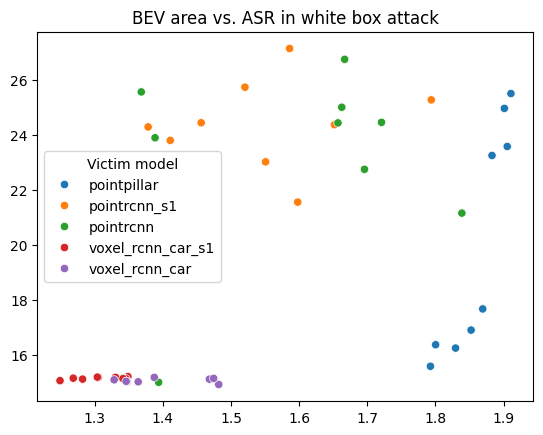

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data_x = []
data_y = []
data_cat = []

for model_name, sub_dict in evaluation_results_metric.items():
    for attack_method, eval_dict in sub_dict.items():
        data_x.append(eval_dict["Meshes_BEV_Area"])
        data_y.append(eval_dict["CAR_BEV"])
        data_cat.append(model_name)

sns.scatterplot(x=data_x,
                y=data_y,
                hue=data_cat,
                # palette={'A': 'red', 'B': 'green', 'C': 'blue'},
                )
plt.title("BEV area vs. ASR in white box attack")
plt.legend(title='Victim model')
plt.show()

In [9]:
import os
import re
import json
from collections import defaultdict


LEVEL_ABLATION_ROOT_PATH = "output/train/transfer_eval"

# PointRCNN PointPillar PVRCNN VoxelRCNN SECOND
clean_data = [86.76, 77.57, 
              85.67, 78.67,
              88.92, 84.37,
              89.15, 85.66,
              88.72, 81.82]

def extract_info_from_folder(folder_name):
    # 使用正则表达式提取信息
    match = re.match(r"([a-zA-Z_1]+)_([a-zA-Z]+_[\d]+)", folder_name)
    if match:
        surrogate_model = match.group(1)
        attack_method = match.group(2)
        return surrogate_model, attack_method
    return None

def read_evaluation_result_json(folder_path):
    json_path = os.path.join(folder_path, "evaluation_result.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

def get_folder_info_by_model(directory):
    model_dict = defaultdict(lambda: defaultdict(dict))

    # 遍历指定目录中的文件夹
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)
        model_name = folder_name
        for sub_folder_name in os.listdir(folder_path):
           
            sub_folder_path = os.path.join(folder_path, sub_folder_name)
            if os.path.isdir(sub_folder_path):
                extracted_info = extract_info_from_folder(sub_folder_name)
            if extracted_info:
                surrogate_model, attack_method = extracted_info
                # 读取 evaluation_result.json 文件
                evaluation_result = read_evaluation_result_json(sub_folder_path)
                if evaluation_result is None:
                    continue
                
                ckpt_file = os.path.join(f"output/train/loss_ablation/{surrogate_model}/{attack_method}", 'final_adversarial_patch_checkpoint.pt')
                state_dict = torch.load(ckpt_file)
                universal_adv_patch_car = single_sphere(scale=adv_dataset.CAR_ADV_PATCH_SCALE)
                universal_adv_patch_car.load_parameter(state_dict["universal_adv_patch_car"])
                adv_meshes = universal_adv_patch_car.get_deformed_meshes()
                area = compute_projected_area_with_overlap(adv_meshes.verts_packed().detach().cpu().numpy(),
                                adv_meshes.faces_packed().detach().cpu().numpy())

                model_dict[model_name][surrogate_model][attack_method] = {
                    "evaluation_result": evaluation_result,
                    "CAR_BEV": area
                }

    return model_dict

model_dict = get_folder_info_by_model(LEVEL_ABLATION_ROOT_PATH)
evaluation_results_metric = defaultdict(lambda: defaultdict(dict))

for surrogate_model in ["pointpillar", "pointrcnn_s1", "pointrcnn", "voxel_rcnn_car_s1", "voxel_rcnn_car"]:
    for attack_method in ["misrecognize_9", "misrecognize_10"]:
        for i, victim_model in enumerate(['pointpillar', 'pointrcnn', 'pvrcnn', 'voxel_rcnn_car', 'second']):
            # print("BEV:")
            clean_bev = clean_data[2 * i]
            clean_3d = clean_data[2 * i + 1]
            if surrogate_model not in model_dict[victim_model]:
                continue
            car_bev = (clean_bev - model_dict[victim_model][surrogate_model][attack_method]['evaluation_result']['Car_bev/moderate']) / clean_bev * 100
            car_3d = (clean_3d - model_dict[victim_model][surrogate_model][attack_method]['evaluation_result']['Car_3d/moderate']) / clean_3d * 100
            car_bev_area = model_dict[victim_model][surrogate_model][attack_method]['CAR_BEV']
            evaluation_results_metric[surrogate_model][victim_model][attack_method] = {
                "CAR_BEV": car_bev,
                "CAR_3D": car_3d,
                "Meshes_BEV_Area": car_bev_area,
            }
                

mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex count : torch.Size([162, 3])
mesh vertex coun

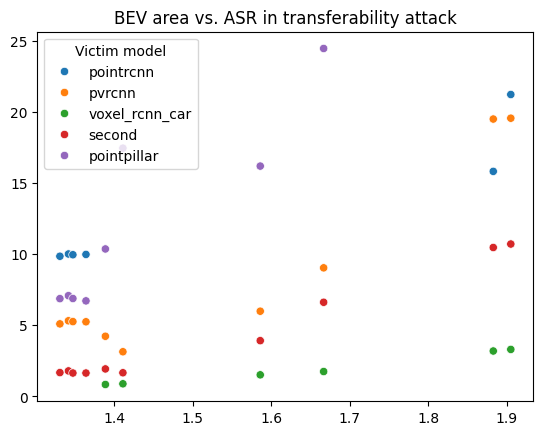

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data_x = []
data_y = []
data_cat = []

for surrogate_model, sub_dict in evaluation_results_metric.items():
    for victim_model, dsub_dict in sub_dict.items():
        for attack_method, eval_dict in dsub_dict.items():
            data_x.append(eval_dict["Meshes_BEV_Area"])
            data_y.append(eval_dict["CAR_BEV"])
            data_cat.append(victim_model)

sns.scatterplot(x=data_x,
                y=data_y,
                hue=data_cat,
                # palette={'A': 'red', 'B': 'green', 'C': 'blue'},
                )
plt.legend(title='Victim model')
plt.title("BEV area vs. ASR in transferability attack")
plt.legend(title='Victim model')
plt.show()